<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-2-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


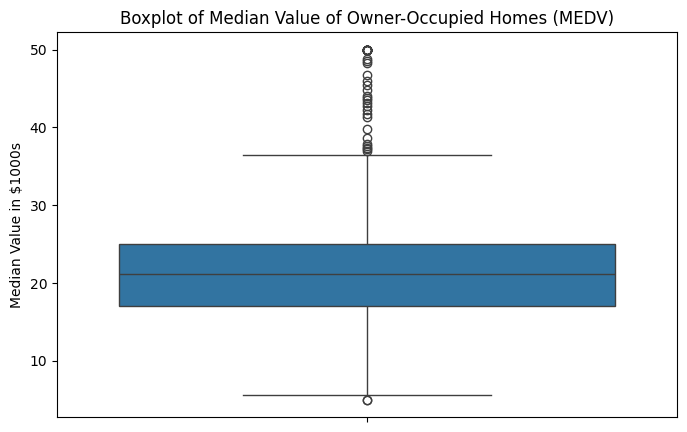

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
plt.figure(figsize=(8, 5))
sns.boxplot(y='MEDV', data=boston_df)
plt.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)')
plt.ylabel('Median Value in $1000s')
plt.show()

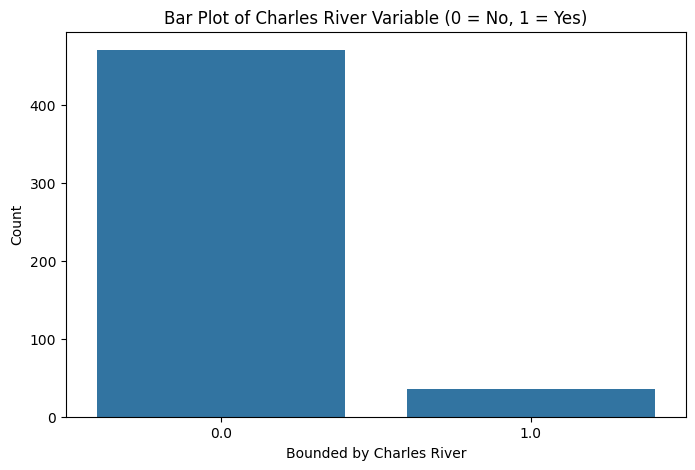

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='CHAS', data=boston_df)
plt.title('Bar Plot of Charles River Variable (0 = No, 1 = Yes)')
plt.xlabel('Bounded by Charles River')
plt.ylabel('Count')
plt.show()

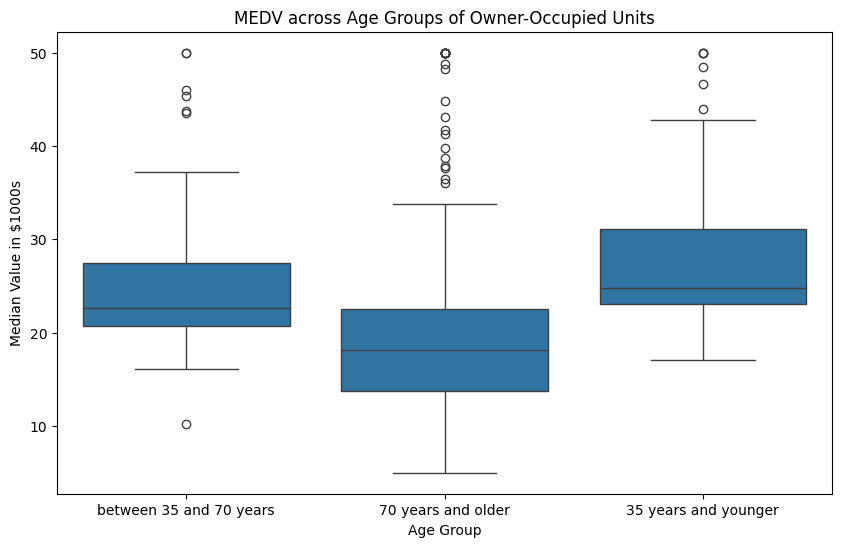

In [8]:
# Discretize AGE into 3 groups
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70), 'age_group'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'age_group'] = '70 years and older'

plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='MEDV', data=boston_df)
plt.title('MEDV across Age Groups of Owner-Occupied Units')
plt.xlabel('Age Group')
plt.ylabel('Median Value in $1000s')
plt.show()

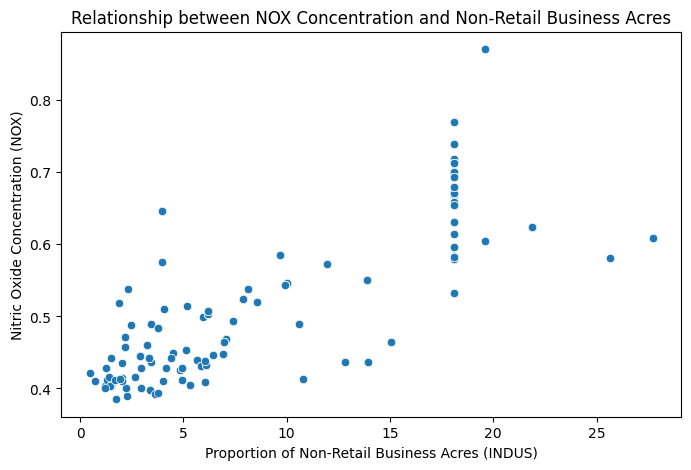

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title('Relationship between NOX Concentration and Non-Retail Business Acres')
plt.xlabel('Proportion of Non-Retail Business Acres (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')
plt.show()

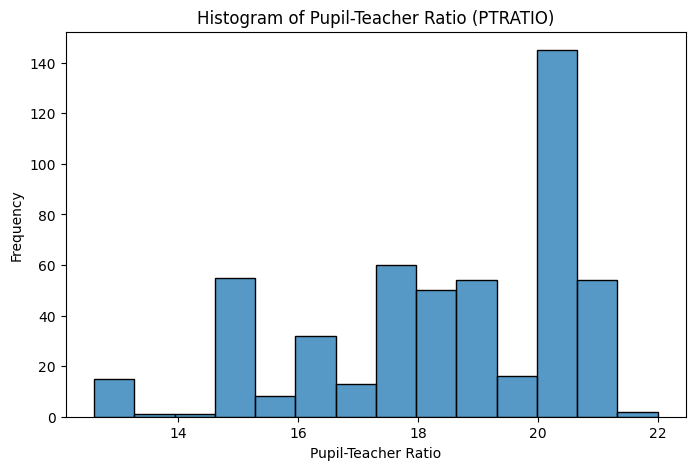

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(boston_df['PTRATIO'], kde=False)
plt.title('Histogram of Pupil-Teacher Ratio (PTRATIO)')
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Frequency')
plt.show()

In [11]:
# Levene's Test for Equality of Variances
levene_stat, levene_p = stats.levene(
    boston_df[boston_df['CHAS'] == 1]['MEDV'],
    boston_df[boston_df['CHAS'] == 0]['MEDV'],
    center='mean'
)
print(f"Levene's Test p-value: {levene_p:.4f}")

# Independent T-Test
ttest_stat, ttest_p = stats.ttest_ind(
    boston_df[boston_df['CHAS'] == 1]['MEDV'],
    boston_df[boston_df['CHAS'] == 0]['MEDV'],
    equal_var=(levene_p > 0.05)
)
print(f"T-Test Statistic: {ttest_stat:.4f}, p-value: {ttest_p:.4f}")

Levene's Test p-value: 0.0032
T-Test Statistic: 3.1133, p-value: 0.0036


In [12]:
group1 = boston_df[boston_df['age_group'] == '35 years and younger']['MEDV']
group2 = boston_df[boston_df['age_group'] == 'between 35 and 70 years']['MEDV']
group3 = boston_df[boston_df['age_group'] == '70 years and older']['MEDV']

f_stat, anova_p = stats.f_oneway(group1, group2, group3)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {anova_p:.4f}")

ANOVA F-statistic: 36.4076, p-value: 0.0000


In [13]:
corr_coeff, corr_p = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}, p-value: {corr_p:.4f}")

Pearson Correlation Coefficient: 0.7637, p-value: 0.0000


In [14]:
X = boston_df['DIS']
y = boston_df['MEDV']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.21e-08
Time:                        09:01:07   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0